In [43]:
pip install streamlit plotly

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [3]:
daily_returns = pd.read_csv(
    "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

daily_returns.head()

,ASIANPAINT.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDALCO.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.034573,0.005925,0.013917,0.010413,-0.003296,0.028385,0.019651,0.003132,0.010289,0.021092,-0.010024,0.005642,0.013689,0.012035,-0.002646,0.003981,0.004926,0.015577,0.013317,0.029897
2015-01-05,-0.000065,-0.022189,-0.008443,-0.020300,0.005754,0.002070,-0.008593,0.003937,-0.004011,0.013912,-0.005063,0.026253,-0.002770,0.001081,-0.010954,-0.007930,0.000605,0.014486,-0.015197,0.002042
2015-01-06,-0.023871,-0.007844,-0.015567,-0.021996,0.018940,-0.042419,-0.020893,-0.025693,-0.011923,-0.033355,-0.005581,-0.015241,-0.033333,-0.022318,-0.045384,-0.041087,-0.022014,-0.048476,-0.036866,-0.028060
2015-01-07,0.020092,0.002400,0.002919,-0.029335,0.035110,-0.027039,0.004785,-0.018598,0.016103,-0.002394,0.010317,0.012518,0.024066,0.014359,0.021768,0.000834,0.001546,-0.019168,-0.011812,-0.003950
2015-01-08,0.063043,0.017324,0.021005,0.024513,0.018893,0.027199,0.005042,0.025032,0.054385,0.006365,0.010987,0.010981,0.016836,0.004356,-0.014339,0.015659,0.011114,0.015557,0.010795,0.025337


In [4]:
print("Start:", daily_returns.index.min())
print("End:", daily_returns.index.max())
print("Number of stocks:", len(daily_returns.columns))

Start: 2015-01-02 00:00:00
End: 2025-12-31 00:00:00
Number of stocks: 20


In [5]:
train_returns = daily_returns.loc[
    "2015-01-01":"2022-12-31"
].copy()

test_returns = daily_returns.loc[
    "2023-01-01":"2025-12-31"
].copy()

print("Training:", train_returns.index.min(), "to", train_returns.index.max())
print("Testing:", test_returns.index.min(), "to", test_returns.index.max())

Training: 2015-01-02 00:00:00 to 2022-12-30 00:00:00
Testing: 2023-01-02 00:00:00 to 2025-12-31 00:00:00


In [6]:
n_assets = len(daily_returns.columns)

initial_weights = np.ones(n_assets) / n_assets

bounds = [
    (0, 0.25)
    for _ in range(n_assets)
]

constraints = [
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }
]

In [7]:
def portfolio_return(weights, expected_returns):
    return np.dot(weights, expected_returns)


def portfolio_volatility(weights, covariance_matrix):
    variance = (
        weights.T
        @ covariance_matrix.values
        @ weights
    )
    
    return np.sqrt(variance)

In [8]:
def optimize_min_variance(returns):
    
    expected_returns = (
        (1 + returns.mean()) ** 252 - 1
    )
    
    covariance_matrix = returns.cov() * 252
    
    def objective(weights):
        return (
            weights.T
            @ covariance_matrix.values
            @ weights
        )
    
    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [9]:
risk_free_rate = 0.06

In [10]:
def optimize_max_sharpe(returns, risk_free_rate=0.06):
    
    expected_returns = (
        (1 + returns.mean()) ** 252 - 1
    )
    
    covariance_matrix = returns.cov() * 252
    
    def negative_sharpe(weights):
        
        ret = np.dot(
            weights,
            expected_returns.values
        )
        
        variance = (
            weights.T
            @ covariance_matrix.values
            @ weights
        )
        
        volatility = np.sqrt(variance)
        
        sharpe = (
            ret - risk_free_rate
        ) / volatility
        
        return -sharpe
    
    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [11]:
test_quarters = test_returns.resample("QE").last().index

test_quarters

DatetimeIndex(['2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31',
               '2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31',
               '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', freq='QE-DEC')

In [12]:
def quarterly_rebalanced_strategy(
    daily_returns,
    start_date="2023-01-01",
    end_date="2025-12-31",
    strategy="minimum_variance",
    lookback_years=3,
    risk_free_rate=0.06
):
    
    test_data = daily_returns.loc[
        start_date:end_date
    ].copy()
    
    portfolio_returns = pd.Series(
        index=test_data.index,
        dtype=float
    )
    
    rebalance_dates = (
        test_data
        .resample("QS")
        .first()
        .index
    )
    
    weights_history = {}
    
    for rebalance_date in rebalance_dates:
        
        # Information available before rebalance date
        estimation_end = rebalance_date - pd.Timedelta(days=1)
        
        estimation_start = (
            estimation_end
            - pd.DateOffset(years=lookback_years)
        )
        
        estimation_returns = daily_returns.loc[
            estimation_start:estimation_end
        ].copy()
        
        # Skip if insufficient history
        if len(estimation_returns) < 252:
            continue
        
        # Select strategy
        if strategy == "minimum_variance":
            
            weights = optimize_min_variance(
                estimation_returns
            )
            
        elif strategy == "maximum_sharpe":
            
            weights = optimize_max_sharpe(
                estimation_returns,
                risk_free_rate
            )
            
        elif strategy == "equal_weight":
            
            weights = np.ones(n_assets) / n_assets
            
        else:
            raise ValueError(
                "Unknown strategy"
            )
        
        weights_history[rebalance_date] = weights
        
        # Determine quarter end
        next_dates = rebalance_dates[
            rebalance_dates > rebalance_date
        ]
        
        if len(next_dates) > 0:
            next_rebalance = next_dates[0]
            period_end = next_rebalance - pd.Timedelta(days=1)
        else:
            period_end = test_data.index.max()
        
        period_returns = test_data.loc[
            rebalance_date:period_end
        ]
        
        portfolio_returns.loc[
            period_returns.index
        ] = period_returns @ weights
    
    portfolio_returns = portfolio_returns.dropna()
    
    return portfolio_returns, weights_history

In [13]:
quarterly_min_var_returns, min_var_weights_history = (
    quarterly_rebalanced_strategy(
        daily_returns,
        strategy="minimum_variance"
    )
)

In [14]:
quarterly_min_var_returns.head()

Date
2023-01-02    0.000742
2023-01-03    0.002529
2023-01-04   -0.007374
2023-01-05    0.005602
2023-01-06   -0.008620
dtype: float64

In [15]:
quarterly_max_sharpe_returns, max_sharpe_weights_history = (
    quarterly_rebalanced_strategy(
        daily_returns,
        strategy="maximum_sharpe"
    )
)

In [16]:
quarterly_equal_weight_returns, equal_weight_weights_history = (
    quarterly_rebalanced_strategy(
        daily_returns,
        strategy="equal_weight"
    )
)

In [17]:
print(
    "Minimum Variance:",
    len(quarterly_min_var_returns)
)

print(
    "Maximum Sharpe:",
    len(quarterly_max_sharpe_returns)
)

print(
    "Equal Weight:",
    len(quarterly_equal_weight_returns)
)

Minimum Variance: 740
Maximum Sharpe: 740
Equal Weight: 740


In [18]:
def risk_contributions(weights, covariance_matrix):
    
    portfolio_variance = (
        weights.T
        @ covariance_matrix.values
        @ weights
    )
    
    portfolio_volatility = np.sqrt(
        portfolio_variance
    )
    
    marginal_contribution = (
        covariance_matrix.values @ weights
    ) / portfolio_volatility
    
    risk_contribution = (
        weights * marginal_contribution
    )
    
    return risk_contribution

In [19]:
def optimize_risk_parity(returns):
    
    covariance_matrix = returns.cov() * 252
    
    n = len(returns.columns)
    
    target_risk = 1 / n
    
    def objective(weights):
        
        contributions = risk_contributions(
            weights,
            covariance_matrix
        )
        
        total_risk = contributions.sum()
        
        risk_budget = (
            contributions / total_risk
        )
        
        return np.sum(
            (risk_budget - target_risk) ** 2
        )
    
    result = minimize(
        objective,
        np.ones(n) / n,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [20]:
risk_parity_weights = optimize_risk_parity(
    train_returns
)

In [21]:
risk_parity_weights_table = pd.DataFrame(
    {
        "Risk Parity": risk_parity_weights
    },
    index=daily_returns.columns
)

risk_parity_weights_table.sort_values(
    "Risk Parity",
    ascending=False
)

,Risk Parity
HINDUNILVR.NS,0.069932
TCS.NS,0.069236
POWERGRID.NS,0.066583
INFY.NS,0.060948
ITC.NS,0.060420
SUNPHARMA.NS,0.056786
ASIANPAINT.NS,0.056333
NTPC.NS,0.055755
HDFCBANK.NS,0.052604
BHARTIARTL.NS,0.051164


In [22]:
print(
    "Weight sum:",
    risk_parity_weights.sum()
)

print(
    "Maximum weight:",
    risk_parity_weights.max()
)

print(
    "Minimum weight:",
    risk_parity_weights.min()
)

Weight sum: 1.0
Maximum weight: 0.0699317526625478
Minimum weight: 0.030139718900434573


In [23]:
test_risk_parity_returns = (
    test_returns @ risk_parity_weights
)

In [24]:
def performance_metrics(
    returns,
    risk_free_rate=0.06
):
    
    returns = (
        pd.Series(returns)
        .dropna()
        .astype(float)
    )
    
    annual_return = (
        (1 + returns).prod()
        ** (252 / len(returns))
        - 1
    )
    
    annual_volatility = (
        returns.std()
        * np.sqrt(252)
    )
    
    sharpe = (
        annual_return
        - risk_free_rate
    ) / annual_volatility
    
    cumulative = (
        1 + returns
    ).cumprod()
    
    running_max = cumulative.cummax()
    
    drawdown = (
        cumulative / running_max
    ) - 1
    
    max_drawdown = drawdown.min()
    
    return {
        "Annual Return": float(annual_return),
        "Annual Volatility": float(annual_volatility),
        "Sharpe Ratio": float(sharpe),
        "Maximum Drawdown": float(max_drawdown)
    }

In [25]:
baseline_performance = pd.read_csv(
    "performance_table.csv",
    index_col=0
)

baseline_performance

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,0.124331,0.111355,0.577712,-0.206221
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535
Equal Weight,0.193013,0.119530,1.112801,-0.161291
Nifty 50,0.131303,0.120165,0.593373,-0.157667


In [26]:
quarterly_results = {
    
    "Quarterly Minimum Variance":
        performance_metrics(
            quarterly_min_var_returns
        ),
    
    "Quarterly Maximum Sharpe":
        performance_metrics(
            quarterly_max_sharpe_returns
        ),
    
    "Quarterly Equal Weight":
        performance_metrics(
            quarterly_equal_weight_returns
        ),
    
    "Risk Parity":
        performance_metrics(
            test_risk_parity_returns
        )
}

robustness_table = pd.DataFrame(
    quarterly_results
).T

robustness_table

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Quarterly Minimum Variance,0.153344,0.104578,0.892581,-0.192556
Quarterly Maximum Sharpe,0.216826,0.143674,1.091537,-0.199010
Quarterly Equal Weight,0.193013,0.119530,1.112801,-0.161291
Risk Parity,0.179076,0.115208,1.033577,-0.169255


In [27]:
all_results = pd.concat(
    [
        baseline_performance,
        robustness_table
    ]
)

all_results

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,0.124331,0.111355,0.577712,-0.206221
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535
Equal Weight,0.193013,0.119530,1.112801,-0.161291
Nifty 50,0.131303,0.120165,0.593373,-0.157667
Quarterly Minimum Variance,0.153344,0.104578,0.892581,-0.192556
Quarterly Maximum Sharpe,0.216826,0.143674,1.091537,-0.199010
Quarterly Equal Weight,0.193013,0.119530,1.112801,-0.161291
Risk Parity,0.179076,0.115208,1.033577,-0.169255


In [28]:
all_results_display = all_results.copy()

for col in [
    "Annual Return",
    "Annual Volatility",
    "Maximum Drawdown"
]:
    
    all_results_display[col] = (
        all_results_display[col] * 100
    ).round(2)

all_results_display["Sharpe Ratio"] = (
    all_results_display["Sharpe Ratio"]
    .round(2)
)

all_results_display

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,12.43,11.14,0.58,-20.62
Maximum Sharpe,8.28,12.48,0.18,-22.65
Equal Weight,19.30,11.95,1.11,-16.13
Nifty 50,13.13,12.02,0.59,-15.77
Quarterly Minimum Variance,15.33,10.46,0.89,-19.26
Quarterly Maximum Sharpe,21.68,14.37,1.09,-19.90
Quarterly Equal Weight,19.30,11.95,1.11,-16.13
Risk Parity,17.91,11.52,1.03,-16.93


In [29]:
wealth = pd.DataFrame()

wealth["Baseline Minimum Variance"] = (
    1 + test_returns @ pd.read_csv(
        "optimized_portfolio_weights.csv",
        index_col=0
    )["Minimum Variance"]
).cumprod()

In [30]:
weights = pd.read_csv(
    "optimized_portfolio_weights.csv",
    index_col=0
)

equal_weights = np.ones(n_assets) / n_assets

wealth["Baseline Maximum Sharpe"] = (
    1 + (
        test_returns
        @ weights["Maximum Sharpe"].values
    )
).cumprod()

wealth["Baseline Equal Weight"] = (
    1 + (
        test_returns
        @ equal_weights
    )
).cumprod()

wealth["Quarterly Minimum Variance"] = (
    1 + quarterly_min_var_returns
).cumprod()

wealth["Quarterly Maximum Sharpe"] = (
    1 + quarterly_max_sharpe_returns
).cumprod()

wealth["Quarterly Equal Weight"] = (
    1 + quarterly_equal_weight_returns
).cumprod()

wealth["Risk Parity"] = (
    1 + test_risk_parity_returns
).cumprod()

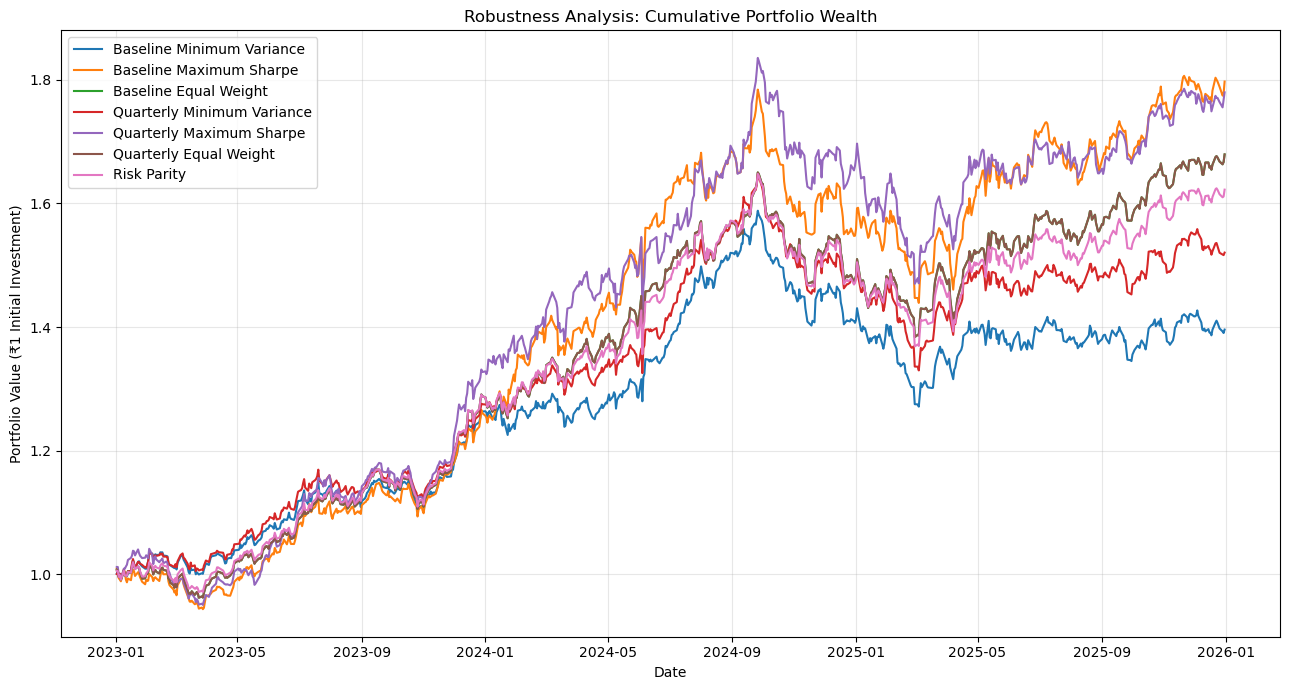

In [31]:
plt.figure(figsize=(13, 7))

for column in wealth.columns:
    
    plt.plot(
        wealth[column],
        label=column
    )

plt.title(
    "Robustness Analysis: Cumulative Portfolio Wealth"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹1 Initial Investment)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
performance_table = pd.read_csv(
    "performance_table.csv",
    index_col=0
)

performance_table

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,0.124331,0.111355,0.577712,-0.206221
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535
Equal Weight,0.193013,0.119530,1.112801,-0.161291
Nifty 50,0.131303,0.120165,0.593373,-0.157667


In [35]:
risk_free_rates = [0.04, 0.06, 0.08]

rf_sensitivity = {}

for rf in risk_free_rates:
    
    row = {}
    
    for portfolio in [
        "Minimum Variance",
        "Maximum Sharpe",
        "Equal Weight",
        "Nifty 50"
    ]:
        
        annual_return = performance_table.loc[
            portfolio,
            "Annual Return"
        ]
        
        volatility = performance_table.loc[
            portfolio,
            "Annual Volatility"
        ]
        
        sharpe = (
            annual_return - rf
        ) / volatility
        
        row[portfolio] = sharpe
    
    rf_sensitivity[
        f"{rf:.0%}"
    ] = row

rf_sensitivity = pd.DataFrame(
    rf_sensitivity
).T

rf_sensitivity

,Minimum Variance,Maximum Sharpe,Equal Weight,Nifty 50
4%,0.757318,0.342646,1.280123,0.759811
6%,0.577712,0.182397,1.112801,0.593373
8%,0.398106,0.022148,0.945478,0.426936


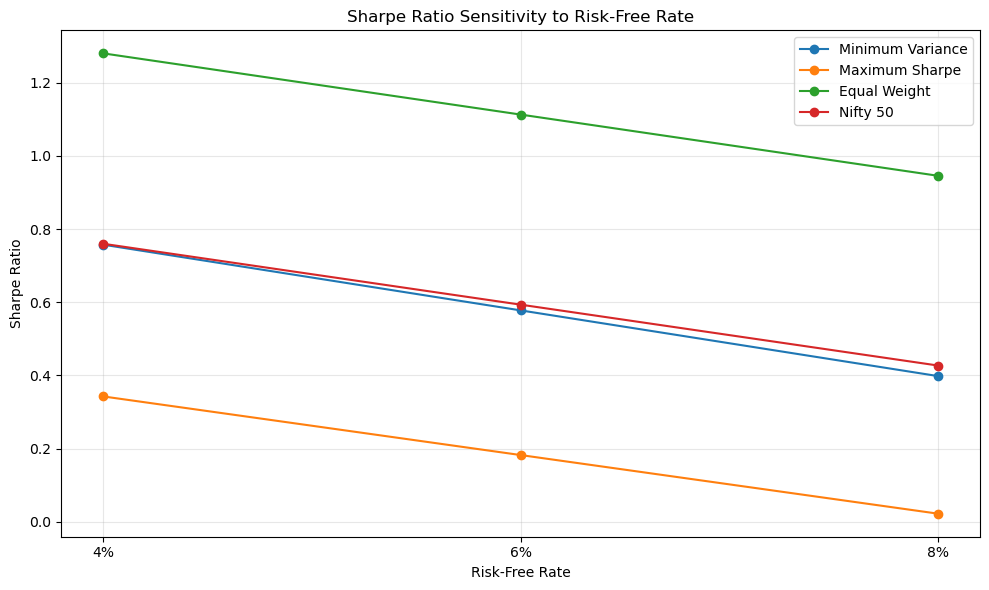

In [36]:
plt.figure(figsize=(10, 6))

for portfolio in rf_sensitivity.columns:
    
    plt.plot(
        rf_sensitivity.index,
        rf_sensitivity[portfolio],
        marker="o",
        label=portfolio
    )

plt.title(
    "Sharpe Ratio Sensitivity to Risk-Free Rate"
)

plt.xlabel("Risk-Free Rate")
plt.ylabel("Sharpe Ratio")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
max_sharpe_weights_df = pd.DataFrame(
    max_sharpe_weights_history,
    index=daily_returns.columns
).T

max_sharpe_weights_df

,ASIANPAINT.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDALCO.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS,ULTRACEMCO.NS
2023-01-01,7.524192e-02,0.000000e+00,5.542253e-16,6.521872e-16,0.000000e+00,8.676955e-17,2.294898e-01,3.022377e-17,2.386954e-16,3.594551e-17,1.556042e-01,6.802214e-16,6.035114e-18,1.304824e-01,1.382710e-16,6.810990e-18,0.250000,1.591817e-01,0.000000e+00,0.000000e+00
2023-04-01,3.490780e-17,9.747451e-17,7.853484e-17,2.162860e-02,4.037806e-17,1.403356e-16,8.725340e-02,2.054436e-01,0.000000e+00,4.851950e-02,2.105841e-01,0.000000e+00,2.749905e-16,7.098844e-02,4.880989e-17,4.936797e-17,0.204228,1.513545e-01,8.037436e-17,9.375182e-17
2023-07-01,1.143704e-01,1.338012e-16,7.263943e-18,7.792372e-18,7.023438e-17,3.341100e-02,2.114323e-02,2.499942e-01,3.302779e-16,8.242114e-02,9.015773e-02,2.599208e-17,3.897768e-17,9.870053e-02,7.633331e-17,8.124978e-02,0.076787,1.517647e-01,3.113789e-17,2.072368e-16
2023-10-01,0.000000e+00,1.666519e-02,0.000000e+00,3.272257e-18,0.000000e+00,2.215574e-02,0.000000e+00,2.500000e-01,0.000000e+00,2.500000e-01,1.395110e-16,0.000000e+00,1.969500e-01,5.381816e-02,0.000000e+00,3.985042e-02,0.103861,6.669931e-02,2.248711e-16,5.268735e-16
2024-01-01,1.856106e-16,5.979542e-02,1.660648e-16,4.494198e-16,1.848202e-16,1.043356e-16,7.311662e-17,2.249233e-01,0.000000e+00,2.016088e-01,2.649089e-02,0.000000e+00,2.500000e-01,9.811363e-02,1.560149e-16,7.972716e-17,0.139068,4.760702e-18,1.662422e-16,6.216176e-16
2024-04-01,3.942548e-16,1.420526e-01,1.276629e-15,4.823142e-16,1.131511e-15,1.457335e-16,0.000000e+00,1.287150e-01,9.461443e-16,1.349412e-01,2.969103e-02,5.067072e-17,2.500000e-01,6.460021e-02,1.584961e-16,0.000000e+00,0.250000,0.000000e+00,0.000000e+00,6.339746e-17
2024-07-01,3.812102e-16,2.085996e-01,0.000000e+00,0.000000e+00,1.018837e-16,7.085006e-16,4.287985e-17,1.454382e-01,0.000000e+00,7.391832e-16,2.386926e-01,0.000000e+00,1.755025e-01,9.975043e-02,0.000000e+00,0.000000e+00,0.132017,0.000000e+00,8.142106e-16,7.183521e-16
2024-10-01,2.048259e-17,1.238636e-01,1.299891e-16,3.535956e-17,6.356094e-16,1.341544e-16,3.702215e-16,1.717404e-01,8.184496e-17,3.855873e-16,2.361977e-01,1.605420e-16,1.724190e-01,8.799400e-02,2.619042e-16,8.555512e-17,0.207785,2.008430e-16,2.703682e-16,1.340601e-16
2025-01-01,2.555043e-16,1.169270e-01,1.873581e-16,5.445830e-16,4.329578e-16,3.891169e-16,5.153902e-16,2.500000e-01,4.314953e-16,3.458720e-16,2.309731e-01,1.351114e-16,1.381902e-01,3.896109e-02,8.471862e-16,1.707702e-16,0.224949,7.093916e-16,4.396035e-16,1.550667e-16
2025-04-01,3.418471e-16,2.177177e-01,6.146539e-16,7.564135e-16,6.440422e-17,2.117002e-02,2.439084e-17,1.443410e-01,1.847940e-18,3.763971e-16,2.500000e-01,2.223291e-16,2.090858e-01,3.484696e-17,8.610160e-16,3.064274e-16,0.157685,6.790840e-16,3.491894e-17,2.089592e-18


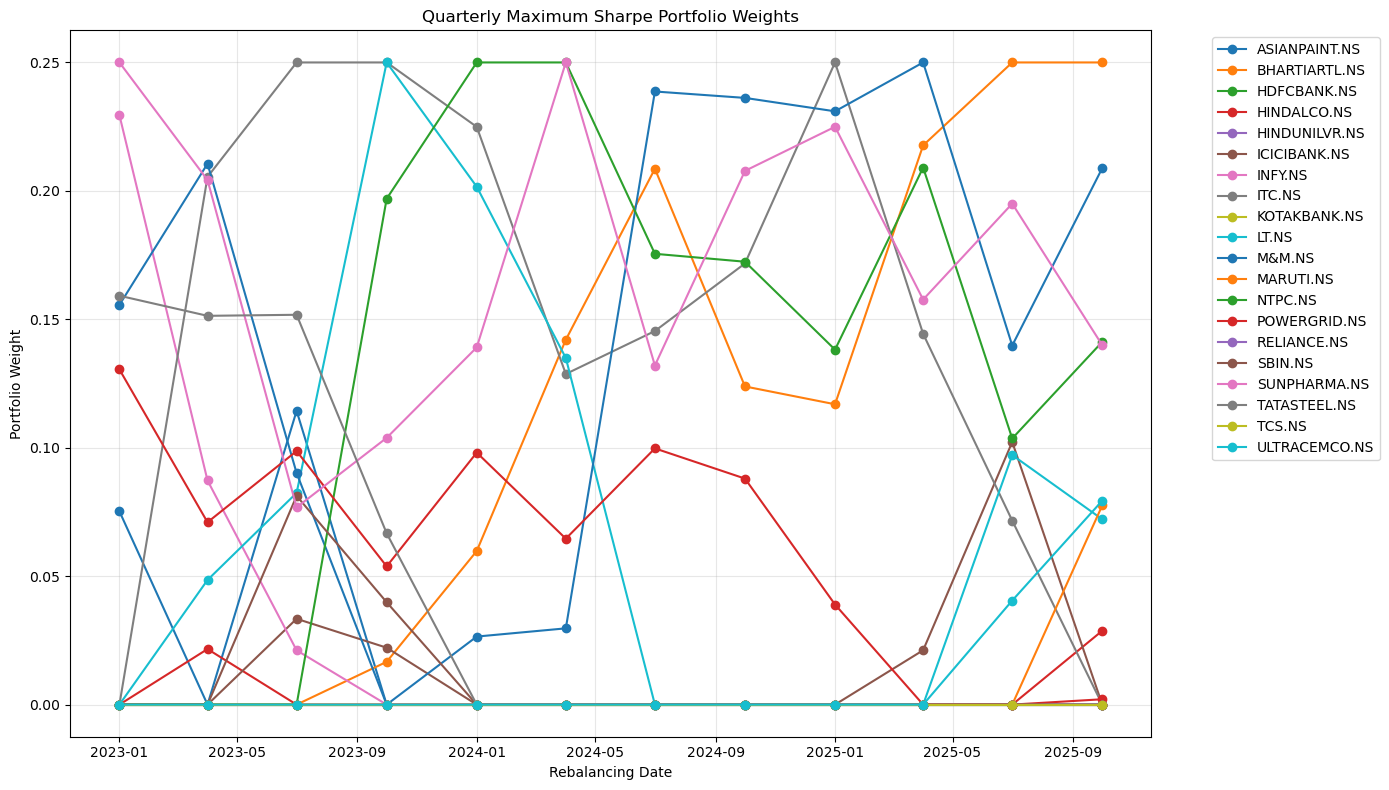

In [38]:
plt.figure(figsize=(14, 8))

for stock in max_sharpe_weights_df.columns:
    
    plt.plot(
        max_sharpe_weights_df.index,
        max_sharpe_weights_df[stock],
        marker="o",
        label=stock
    )

plt.title(
    "Quarterly Maximum Sharpe Portfolio Weights"
)

plt.xlabel("Rebalancing Date")
plt.ylabel("Portfolio Weight")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
weight_changes = (
    max_sharpe_weights_df
    .diff()
    .abs()
)

average_turnover = weight_changes.sum(
    axis=1
).mean()

print(
    "Average absolute weight change:",
    average_turnover
)

Average absolute weight change: 0.4587038484201081


In [40]:
weight_instability = (
    weight_changes.mean()
    .sort_values(
        ascending=False
    )
)

weight_instability.head(10)

ITC.NS           0.067506
SUNPHARMA.NS     0.065190
M&M.NS           0.064573
LT.NS            0.056563
NTPC.NS          0.052346
BHARTIARTL.NS    0.039395
POWERGRID.NS     0.031535
ASIANPAINT.NS    0.027635
ICICIBANK.NS     0.024663
INFY.NS          0.020863
dtype: float64

In [41]:
all_results.to_csv(
    "robustness_performance_table.csv"
)

risk_parity_weights_table.to_csv(
    "risk_parity_weights.csv"
)

rf_sensitivity.to_csv(
    "risk_free_sensitivity.csv"
)

max_sharpe_weights_df.to_csv(
    "quarterly_max_sharpe_weights.csv"
)

wealth.to_csv(
    "robustness_wealth_paths.csv"
)

print("Robustness analysis files saved.")

Robustness analysis files saved.


In [42]:
print("=" * 60)
print("FINAL ROBUSTNESS ANALYSIS")
print("=" * 60)

print("\nBest baseline strategy by Sharpe:")
print(
    baseline_performance["Sharpe Ratio"].idxmax()
)

print(
    "Sharpe:",
    round(
        baseline_performance["Sharpe Ratio"].max(),
        3
    )
)

print("\nBest robustness strategy by Sharpe:")
print(
    robustness_table["Sharpe Ratio"].idxmax()
)

print(
    "Sharpe:",
    round(
        robustness_table["Sharpe Ratio"].max(),
        3
    )
)

print("\nLowest volatility across robustness strategies:")
print(
    robustness_table["Annual Volatility"].idxmin()
)

print(
    "Volatility:",
    f"{robustness_table['Annual Volatility'].min():.2%}"
)

print("\nHighest return across robustness strategies:")
print(
    robustness_table["Annual Return"].idxmax()
)

print(
    "Return:",
    f"{robustness_table['Annual Return'].max():.2%}"
)

FINAL ROBUSTNESS ANALYSIS

Best baseline strategy by Sharpe:
Equal Weight
Sharpe: 1.113

Best robustness strategy by Sharpe:
Quarterly Equal Weight
Sharpe: 1.113

Lowest volatility across robustness strategies:
Quarterly Minimum Variance
Volatility: 10.46%

Highest return across robustness strategies:
Quarterly Maximum Sharpe
Return: 21.68%
